# ARCADE Beginner Notebook: EDA + Train + Test (Segmentation)

This notebook is made simple for beginners.

What this notebook does:
- Load ARCADE data (`stenosis` or `syntax`)
- Do basic EDA
- Build binary masks from polygon annotations
- Train a small segmentation model
- Test the model with Dice and IoU metrics

## First Time Setup (Windows CMD)
Open terminal in project root and run:

```bash
python -m venv venv
venv\Scripts\activate
pip install -r requirements.txt
python -m ipykernel install --user --name arcade-venv --display-name "Python (arcade-venv)"
```

Then select kernel: **Python (arcade-venv)**.

In [29]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Change this to 'stenosis' or 'syntax'
dataset_name = 'syntax'

# Keep this small for beginner-friendly fast experiments
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-3

# Project root from notebook location: archive/notebooks/*.ipynb
project_root = Path.cwd().parent
print('Project root:', project_root)

Torch version: 2.10.0+cpu
CUDA available: False
Using device: cpu
Project root: c:\Users\kdkav\Desktop\rishav mutthal\archive


In [30]:
def get_split_paths(root: Path, ds_name: str, split: str):
    img_dir = root / 'data' / ds_name / split / 'images'
    ann_path = root / 'data' / ds_name / split / 'annotations' / f'{split}.json'
    return img_dir, ann_path


def load_coco_json(json_path: Path):
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)


def build_image_lookup(coco_data):
    image_lookup = {}
    for item in coco_data['images']:
        image_lookup[item['id']] = item['file_name']
    return image_lookup


def build_annotations_lookup(coco_data):
    anns_lookup = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        anns_lookup.setdefault(img_id, []).append(ann)
    return anns_lookup


splits = ['train', 'val', 'test']
data_info = {}
for split in splits:
    img_dir, ann_path = get_split_paths(project_root, dataset_name, split)
    coco = load_coco_json(ann_path)
    data_info[split] = {
        'img_dir': img_dir,
        'ann_path': ann_path,
        'coco': coco,
        'image_lookup': build_image_lookup(coco),
        'anns_lookup': build_annotations_lookup(coco)
    }

print('Loaded dataset:', dataset_name)
for split in splits:
    coco = data_info[split]['coco']
    print(split, '-> images:', len(coco['images']), '| annotations:', len(coco['annotations']), '| categories:', len(coco['categories']))

Loaded dataset: syntax
train -> images: 1000 | annotations: 4976 | categories: 26
val -> images: 200 | annotations: 1168 | categories: 26
test -> images: 300 | annotations: 1672 | categories: 26


,split,images,annotations,categories
0,train,1000,4976,26
1,val,200,1168,26
2,test,300,1672,26


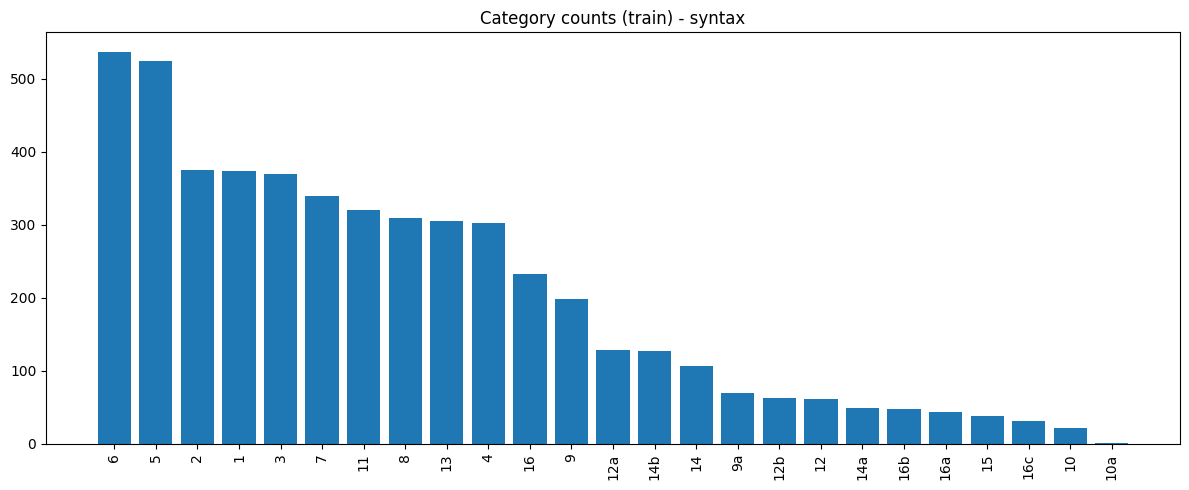

In [31]:
# Simple EDA summary table
rows = []
for split in splits:
    coco = data_info[split]['coco']
    rows.append({
        'split': split,
        'images': len(coco['images']),
        'annotations': len(coco['annotations']),
        'categories': len(coco['categories'])
    })

df_summary = pd.DataFrame(rows)
display(df_summary)

# Category distribution on train split
train_coco = data_info['train']['coco']
cat_id_to_name = {c['id']: c['name'] for c in train_coco['categories']}
cat_counts = {}
for ann in train_coco['annotations']:
    cid = ann['category_id']
    cat_counts[cid] = cat_counts.get(cid, 0) + 1

cat_df = pd.DataFrame([
    {'category_id': cid, 'category_name': cat_id_to_name.get(cid, str(cid)), 'count': count}
    for cid, count in cat_counts.items()
]).sort_values('count', ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(cat_df['category_name'].astype(str), cat_df['count'])
plt.title(f'Category counts (train) - {dataset_name}')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Advanced EDA: Multi-Graph Comparisons

This section compares both tasks (`stenosis` and `syntax`) across `train`, `val`, and `test`.

You will get:
- Images and annotations count comparisons
- Annotations-per-image distribution comparisons
- Category count comparisons
- Polygon complexity comparisons

,task,split,images,annotations,categories,mean_annotations_per_labeled_image,median_annotations_per_labeled_image
2,stenosis,test,300,386,26,1.286667,1.0
0,stenosis,train,1000,1625,26,1.629890,1.0
1,stenosis,val,200,406,26,2.030000,2.0
5,syntax,test,300,1672,26,5.573333,5.0
3,syntax,train,1000,4976,26,4.976000,5.0
4,syntax,val,200,1168,26,5.840000,6.0


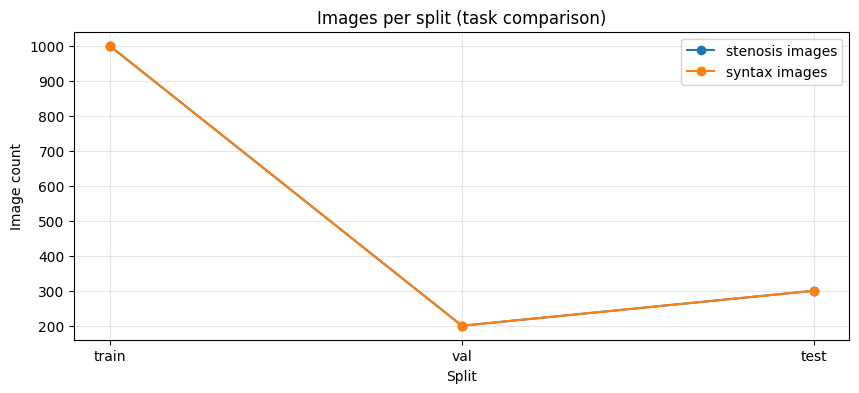

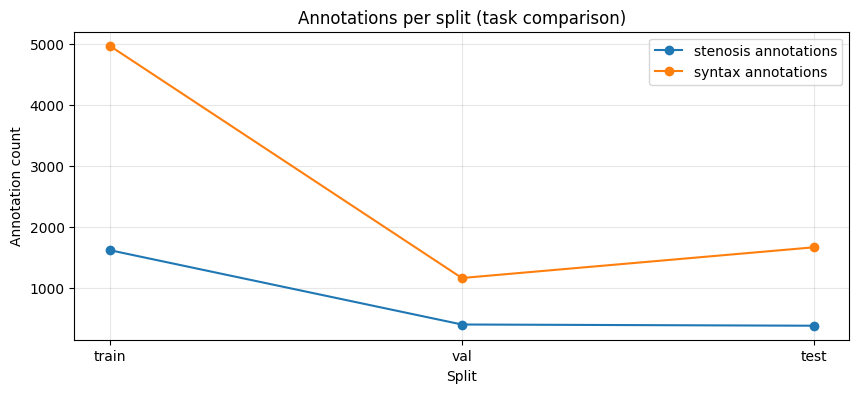

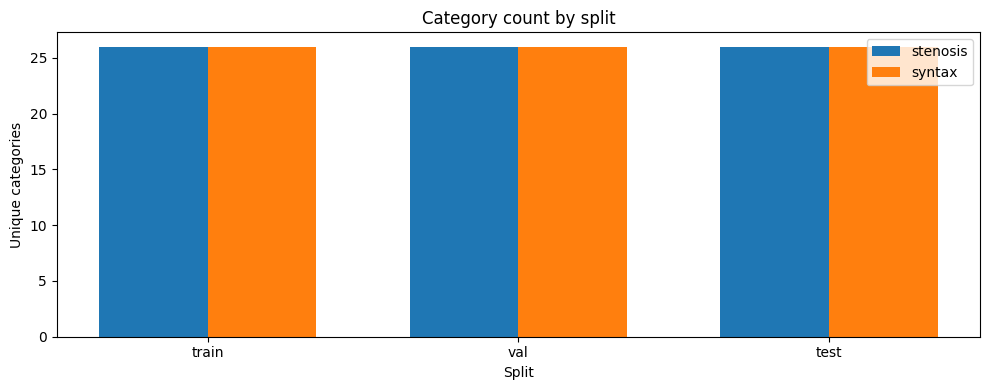

In [32]:
def load_task_split(task_name, split_name):
    img_dir, ann_path = get_split_paths(project_root, task_name, split_name)
    coco = load_coco_json(ann_path)
    return {
        'task': task_name,
        'split': split_name,
        'img_dir': img_dir,
        'coco': coco,
        'image_lookup': build_image_lookup(coco),
        'anns_lookup': build_annotations_lookup(coco)
    }


all_tasks = ['stenosis', 'syntax']
all_splits = ['train', 'val', 'test']
all_data = [load_task_split(task, split) for task in all_tasks for split in all_splits]

# Build split-level summary table
summary_rows = []
for item in all_data:
    coco = item['coco']
    anns_per_image = {}
    for ann in coco['annotations']:
        image_id = ann['image_id']
        anns_per_image[image_id] = anns_per_image.get(image_id, 0) + 1

    ann_counts = list(anns_per_image.values())
    mean_anns = float(np.mean(ann_counts)) if len(ann_counts) > 0 else 0.0
    median_anns = float(np.median(ann_counts)) if len(ann_counts) > 0 else 0.0

    summary_rows.append({
        'task': item['task'],
        'split': item['split'],
        'images': len(coco['images']),
        'annotations': len(coco['annotations']),
        'categories': len(coco['categories']),
        'mean_annotations_per_labeled_image': mean_anns,
        'median_annotations_per_labeled_image': median_anns
    })

adv_summary_df = pd.DataFrame(summary_rows)
display(adv_summary_df.sort_values(['task', 'split']))

# Plot 1: image count comparison
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['images'], marker='o', label=f'{task} images')
plt.title('Images per split (task comparison)')
plt.xlabel('Split')
plt.ylabel('Image count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 2: annotation count comparison
plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = adv_summary_df[adv_summary_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['annotations'], marker='o', label=f'{task} annotations')
plt.title('Annotations per split (task comparison)')
plt.xlabel('Split')
plt.ylabel('Annotation count')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 3: category count comparison
plt.figure(figsize=(10, 4))
x = np.arange(len(all_splits))
width = 0.35
stenosis_cat = adv_summary_df[adv_summary_df['task'] == 'stenosis'].set_index('split').reindex(all_splits)['categories'].values
syntax_cat = adv_summary_df[adv_summary_df['task'] == 'syntax'].set_index('split').reindex(all_splits)['categories'].values

plt.bar(x - width/2, stenosis_cat, width, label='stenosis')
plt.bar(x + width/2, syntax_cat, width, label='syntax')
plt.xticks(x, all_splits)
plt.title('Category count by split')
plt.xlabel('Split')
plt.ylabel('Unique categories')
plt.legend()
plt.tight_layout()
plt.show()

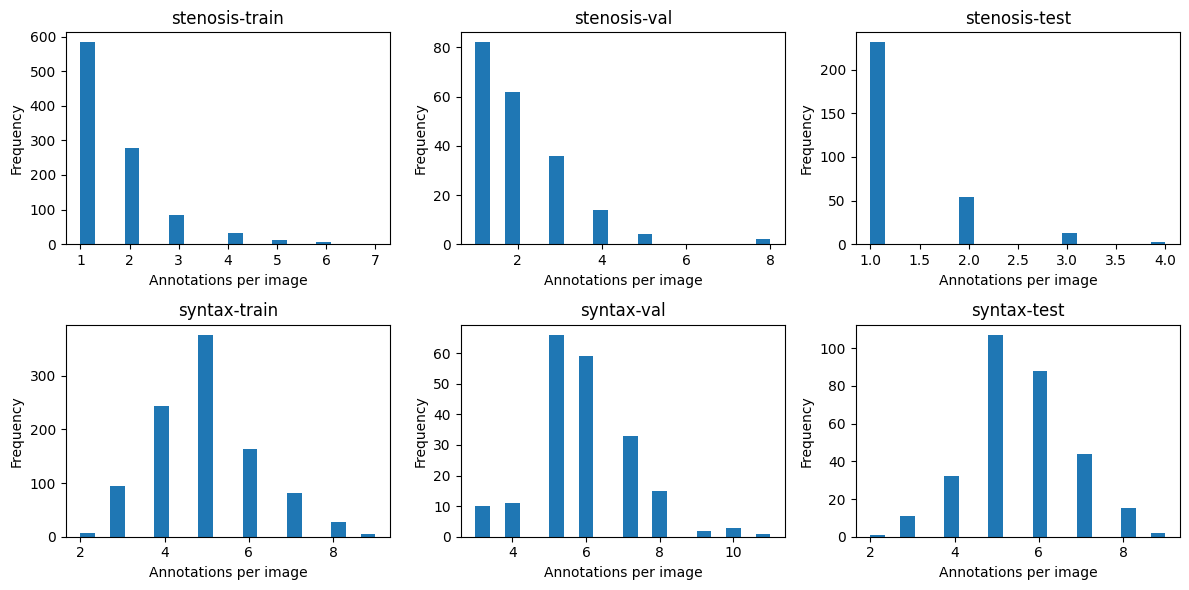

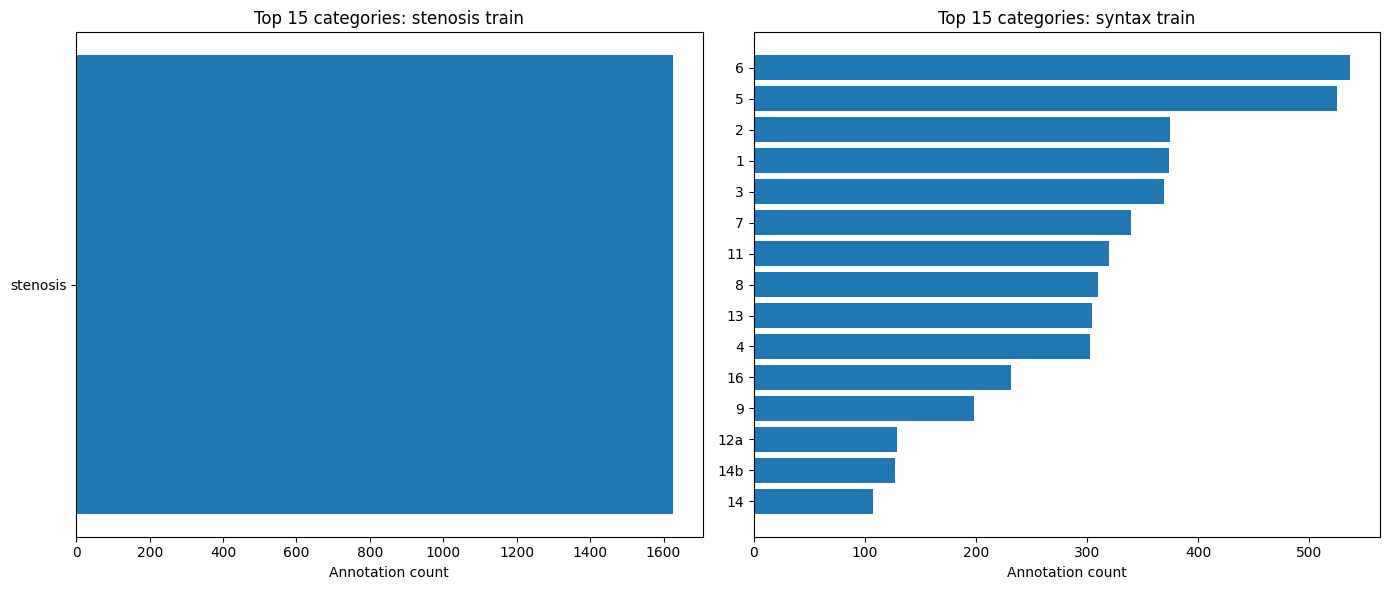

In [33]:
# Plot 4: annotations per image distribution by task and split
plt.figure(figsize=(12, 6))
plot_idx = 1
for task in all_tasks:
    for split in all_splits:
        item = next(x for x in all_data if x['task'] == task and x['split'] == split)
        coco = item['coco']

        anns_per_image = {}
        for ann in coco['annotations']:
            image_id = ann['image_id']
            anns_per_image[image_id] = anns_per_image.get(image_id, 0) + 1

        values = list(anns_per_image.values())
        if len(values) == 0:
            values = [0]

        plt.subplot(2, 3, plot_idx)
        plt.hist(values, bins=20)
        plt.title(f'{task}-{split}')
        plt.xlabel('Annotations per image')
        plt.ylabel('Frequency')
        plot_idx += 1

plt.tight_layout()
plt.show()

# Plot 5: top categories in train split (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

for ax, task in zip(axes, all_tasks):
    item = next(x for x in all_data if x['task'] == task and x['split'] == 'train')
    coco = item['coco']
    cat_id_to_name = {c['id']: c['name'] for c in coco['categories']}

    cat_counts = {}
    for ann in coco['annotations']:
        cid = ann['category_id']
        cat_counts[cid] = cat_counts.get(cid, 0) + 1

    df = pd.DataFrame([
        {'category': cat_id_to_name.get(cid, str(cid)), 'count': cnt}
        for cid, cnt in cat_counts.items()
    ]).sort_values('count', ascending=False).head(15)

    ax.barh(df['category'].astype(str), df['count'])
    ax.invert_yaxis()
    ax.set_title(f'Top 15 categories: {task} train')
    ax.set_xlabel('Annotation count')

plt.tight_layout()
plt.show()

,task,split,mean_points,median_points,p90_points
2,stenosis,test,19.430052,17.0,32.5
0,stenosis,train,23.857846,18.0,46.0
1,stenosis,val,20.369458,17.0,31.0
5,syntax,test,91.656699,71.0,174.0
3,syntax,train,83.072146,61.5,176.0
4,syntax,val,79.702055,61.0,164.0


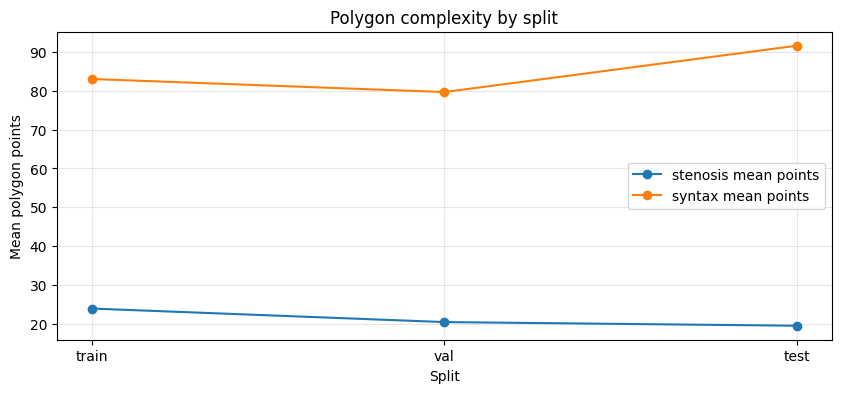

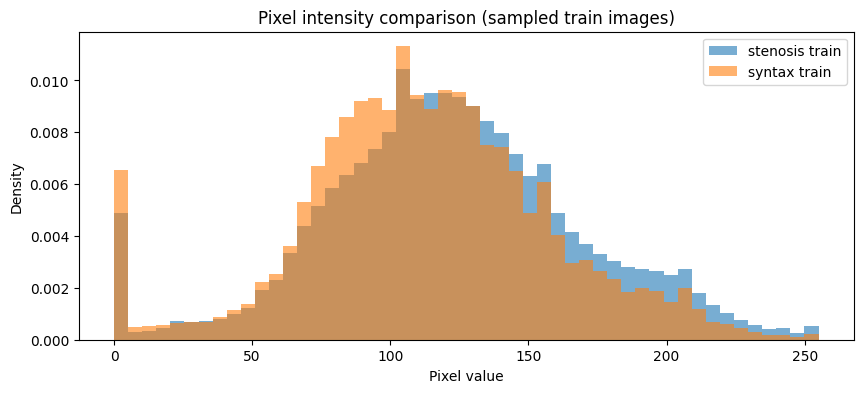

In [34]:
# Plot 6: polygon complexity comparison (number of points per polygon)
complexity_rows = []

for item in all_data:
    task = item['task']
    split = item['split']
    coco = item['coco']

    point_counts = []
    for ann in coco['annotations']:
        seg = ann.get('segmentation', [])
        if not isinstance(seg, list):
            continue
        for poly in seg:
            n_points = len(poly) // 2
            if n_points > 0:
                point_counts.append(n_points)

    if len(point_counts) == 0:
        point_counts = [0]

    complexity_rows.append({
        'task': task,
        'split': split,
        'mean_points': float(np.mean(point_counts)),
        'median_points': float(np.median(point_counts)),
        'p90_points': float(np.percentile(point_counts, 90))
    })

complexity_df = pd.DataFrame(complexity_rows)
display(complexity_df.sort_values(['task', 'split']))

plt.figure(figsize=(10, 4))
for task in all_tasks:
    d = complexity_df[complexity_df['task'] == task].set_index('split').reindex(all_splits)
    plt.plot(all_splits, d['mean_points'], marker='o', label=f'{task} mean points')
plt.title('Polygon complexity by split')
plt.xlabel('Split')
plt.ylabel('Mean polygon points')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot 7: sampled image intensity histograms (task-level)
def sample_intensities(task_name, max_images=120):
    item = next(x for x in all_data if x['task'] == task_name and x['split'] == 'train')
    img_dir = item['img_dir']
    images = item['coco']['images']

    sample = images if len(images) <= max_images else random.sample(images, max_images)
    pixels = []

    for im in sample:
        arr = cv2.imread(str(img_dir / im['file_name']), cv2.IMREAD_GRAYSCALE)
        if arr is not None:
            pixels.append(arr.flatten())

    if len(pixels) == 0:
        return np.array([0], dtype=np.uint8)

    return np.concatenate(pixels)

stenosis_pixels = sample_intensities('stenosis')
syntax_pixels = sample_intensities('syntax')

plt.figure(figsize=(10, 4))
plt.hist(stenosis_pixels, bins=50, alpha=0.6, density=True, label='stenosis train')
plt.hist(syntax_pixels, bins=50, alpha=0.6, density=True, label='syntax train')
plt.title('Pixel intensity comparison (sampled train images)')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.legend()
plt.show()

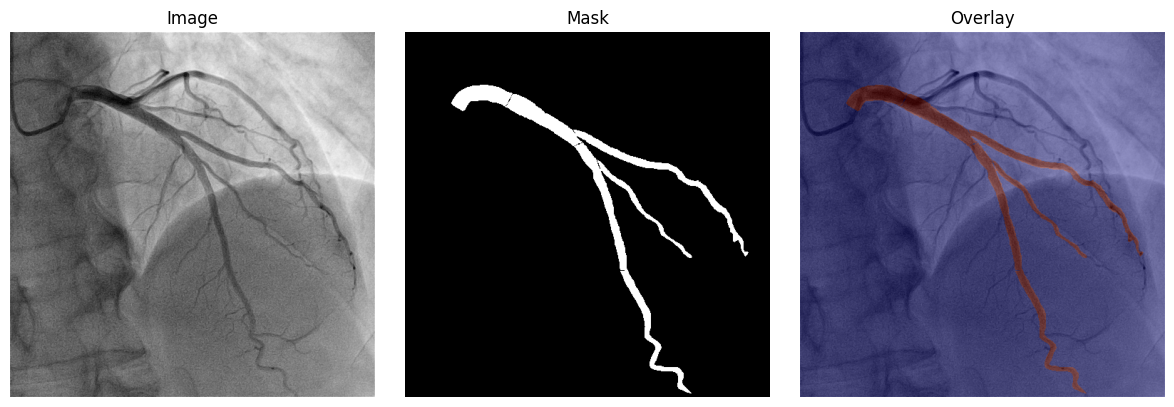

In [35]:
def polygons_to_mask(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for ann in annotations:
        seg = ann.get('segmentation', [])
        if not isinstance(seg, list):
            continue
        for poly in seg:
            pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
            pts = np.round(pts).astype(np.int32)
            if pts.shape[0] >= 3:
                cv2.fillPoly(mask, [pts], 1)
    return mask


def show_random_overlay(split='train'):
    split_info = data_info[split]
    coco = split_info['coco']
    image_lookup = split_info['image_lookup']
    anns_lookup = split_info['anns_lookup']
    img_dir = split_info['img_dir']

    img_item = random.choice(coco['images'])
    img_id = img_item['id']
    file_name = image_lookup[img_id]

    image = cv2.imread(str(img_dir / file_name), cv2.IMREAD_GRAYSCALE)
    anns = anns_lookup.get(img_id, [])
    mask = polygons_to_mask(anns, image.shape[0], image.shape[1])

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image, cmap='gray')
    plt.imshow(mask, cmap='jet', alpha=0.4)
    plt.title('Overlay')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


show_random_overlay('train')

In [36]:
class ArcadeSegDataset(Dataset):
    def __init__(self, split_info, image_size=256):
        self.coco = split_info['coco']
        self.image_lookup = split_info['image_lookup']
        self.anns_lookup = split_info['anns_lookup']
        self.img_dir = split_info['img_dir']
        self.images = self.coco['images']
        self.image_size = image_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        item = self.images[idx]
        img_id = item['id']
        file_name = self.image_lookup[img_id]

        image = cv2.imread(str(self.img_dir / file_name), cv2.IMREAD_GRAYSCALE)
        if image is None:
            image = np.zeros((512, 512), dtype=np.uint8)

        anns = self.anns_lookup.get(img_id, [])
        mask = polygons_to_mask(anns, image.shape[0], image.shape[1])

        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32)

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image), torch.tensor(mask)


train_ds = ArcadeSegDataset(data_info['train'], image_size=IMG_SIZE)
val_ds = ArcadeSegDataset(data_info['val'], image_size=IMG_SIZE)
test_ds = ArcadeSegDataset(data_info['test'], image_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))
print('Test batches:', len(test_loader))

Train batches: 250
Val batches: 50
Test batches: 75


In [37]:
class TinyUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1),
            nn.ReLU()
        )

        self.out_conv = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u1 = self.up1(b)
        d1 = self.dec1(torch.cat([u1, e2], dim=1))

        u2 = self.up2(d1)
        d2 = self.dec2(torch.cat([u2, e1], dim=1))

        return self.out_conv(d2)


model = TinyUNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model.__class__.__name__)
print('Model parameters:', sum(p.numel() for p in model.parameters()))

TinyUNet
Model parameters: 116753


Epoch 1/20 | Train Loss: 0.1794 | Val Loss: 0.1514
Epoch 2/20 | Train Loss: 0.1279 | Val Loss: 0.1451
Epoch 3/20 | Train Loss: 0.0991 | Val Loss: 0.0957
Epoch 4/20 | Train Loss: 0.0812 | Val Loss: 0.0852
Epoch 5/20 | Train Loss: 0.0723 | Val Loss: 0.0976
Epoch 6/20 | Train Loss: 0.0660 | Val Loss: 0.0686
Epoch 7/20 | Train Loss: 0.0620 | Val Loss: 0.0694
Epoch 8/20 | Train Loss: 0.0580 | Val Loss: 0.0658
Epoch 9/20 | Train Loss: 0.0562 | Val Loss: 0.0625
Epoch 10/20 | Train Loss: 0.0540 | Val Loss: 0.0641
Epoch 11/20 | Train Loss: 0.0516 | Val Loss: 0.0586
Epoch 12/20 | Train Loss: 0.0502 | Val Loss: 0.0609
Epoch 13/20 | Train Loss: 0.0497 | Val Loss: 0.0579
Epoch 14/20 | Train Loss: 0.0484 | Val Loss: 0.0533
Epoch 15/20 | Train Loss: 0.0477 | Val Loss: 0.0561
Epoch 16/20 | Train Loss: 0.0464 | Val Loss: 0.0512
Epoch 17/20 | Train Loss: 0.0460 | Val Loss: 0.0508
Epoch 18/20 | Train Loss: 0.0463 | Val Loss: 0.0531
Epoch 19/20 | Train Loss: 0.0451 | Val Loss: 0.0525
Epoch 20/20 | Train L

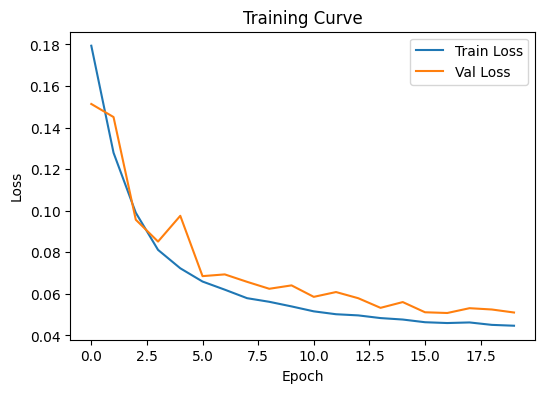

In [38]:
def run_epoch(model, loader, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')


plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
def dice_score(pred_mask, true_mask, eps=1e-6):
    intersection = (pred_mask * true_mask).sum()
    total = pred_mask.sum() + true_mask.sum()
    return (2 * intersection + eps) / (total + eps)


def iou_score(pred_mask, true_mask, eps=1e-6):
    intersection = (pred_mask * true_mask).sum()
    union = pred_mask.sum() + true_mask.sum() - intersection
    return (intersection + eps) / (union + eps)


model.eval()
dice_list = []
iou_list = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        for i in range(images.shape[0]):
            d = dice_score(preds[i], masks[i]).item()
            j = iou_score(preds[i], masks[i]).item()
            dice_list.append(d)
            iou_list.append(j)

print('Test Dice:', float(np.mean(dice_list)))
print('Test IoU :', float(np.mean(iou_list)))

Test Dice: 0.6321454491714636
Test IoU : 0.47861119562139115


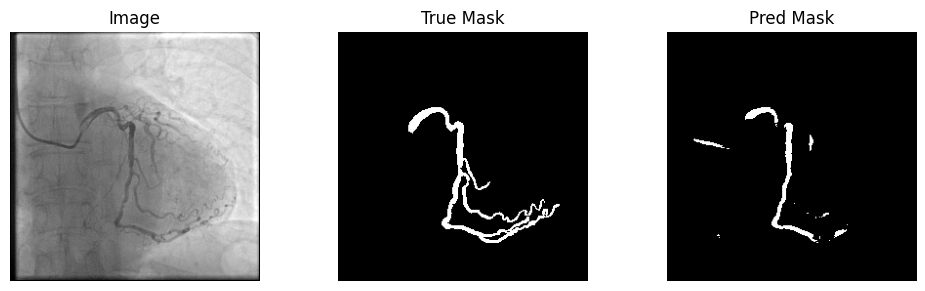

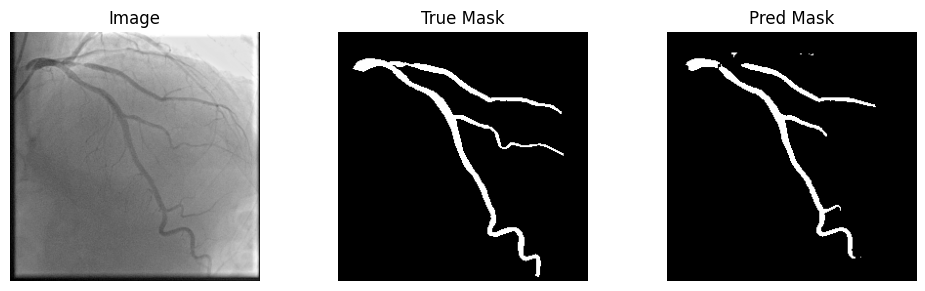

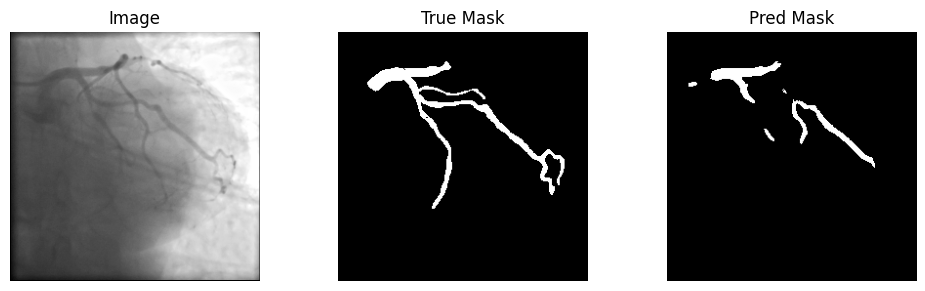

In [40]:
# Show a few test predictions
model.eval()
shown = 0
max_show = 3

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        probs = torch.sigmoid(model(images))
        preds = (probs > 0.5).float()

        for i in range(images.shape[0]):
            if shown >= max_show:
                break

            img = images[i, 0].cpu().numpy()
            true_m = masks[i, 0].cpu().numpy()
            pred_m = preds[i, 0].cpu().numpy()

            plt.figure(figsize=(10, 3))
            plt.subplot(1, 3, 1)
            plt.imshow(img, cmap='gray')
            plt.title('Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_m, cmap='gray')
            plt.title('True Mask')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_m, cmap='gray')
            plt.title('Pred Mask')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

            shown += 1

        if shown >= max_show:
            break

## Notes

- To run on the second task, set `dataset_name = 'syntax'` in the config cell and rerun all cells.
- For first experiments, keep `EPOCHS = 2` so it runs quickly.
- This notebook uses **binary mask segmentation** for simplicity.

Simple next improvements (optional):
- Increase epochs
- Add basic data augmentation
- Save the best model